In [31]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols, glm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import t
import matplotlib.pyplot as plt

In [32]:
dat = pd.read_csv('data/co2_daily_mlo.csv', comment='#', header=None)
dat.columns = ['year', 'month', 'day', 'decimal_date', 'pCO2']
# dat.set_index('decimal_date', inplace=True)

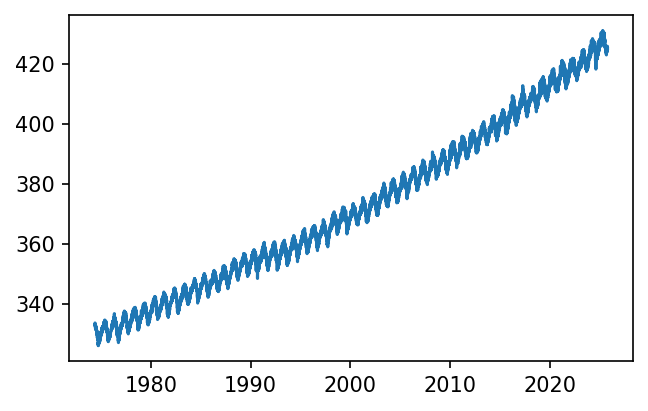

In [33]:
plt.plot(dat['decimal_date'], dat['pCO2'])

## Trend

In [34]:
naive_model = ols('pCO2 ~ decimal_date', data=dat).fit()
print(naive_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 8.480e+05
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:31:26   Log-Likelihood:                -43006.
No. Observations:               15759   AIC:                         8.602e+04
Df Residuals:                   15757   BIC:                         8.603e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.3431      4.075   -829.017   

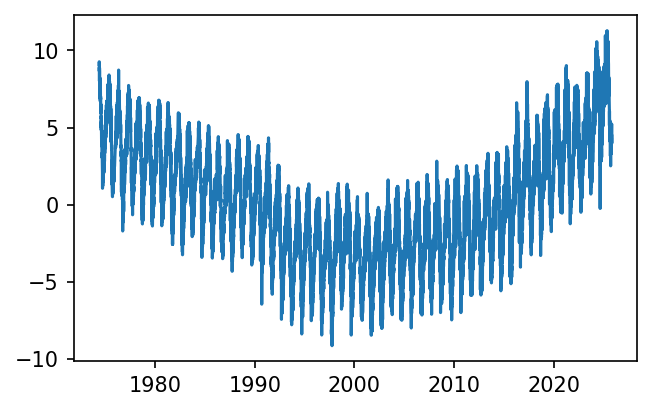

In [35]:
plt.plot(dat['decimal_date'], naive_model.resid)

In [41]:
dat['sin_annual'] = np.sin(2 * np.pi * dat['decimal_date'])
dat['cos_annual'] = np.cos(2 * np.pi * dat['decimal_date'])

harmonic_model_formula = 'pCO2 ~ decimal_date + sin_annual + cos_annual'
harmonic_model = ols(harmonic_model_formula, data=dat).fit()
print(harmonic_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   pCO2   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 4.176e+05
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:35:46   Log-Likelihood:                -39976.
No. Observations:               15759   AIC:                         7.996e+04
Df Residuals:                   15755   BIC:                         7.999e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -3378.6789      3.363  -1004.777   

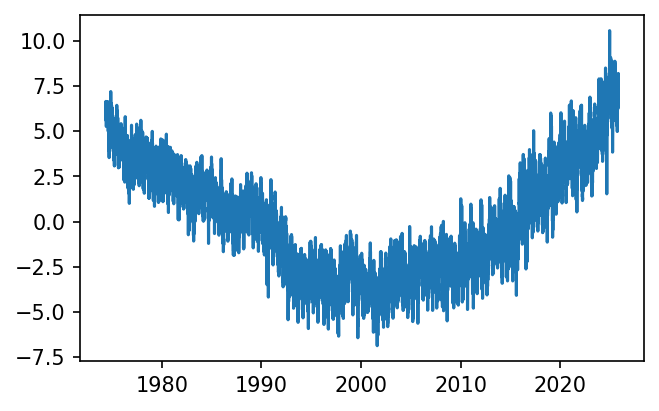

In [42]:
plt.plot(dat['decimal_date'], harmonic_model.resid)

In [ ]:
exog_vars = ['decimal_date', 'sin_annual', 'cos_annual']
exog = dat[exog_vars]

gls_model = sm.GLS(dat['pCO2'], exog, missing='drop').fit(
    # Fit with the AR(1) structure derived from the residuals in Stage 2
    # The 'rho' is the estimated autocorrelation parameter
    method='qr',
    reml=False
)




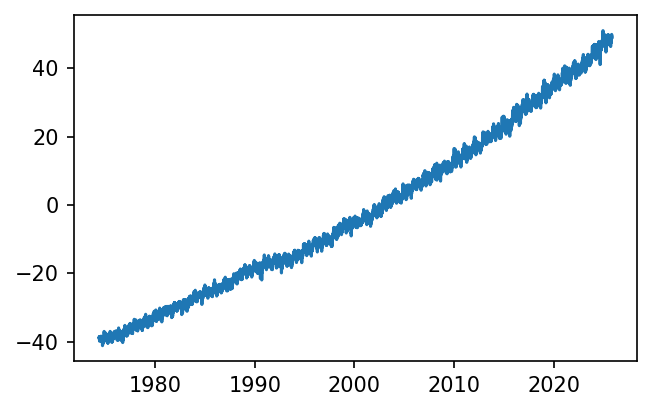

In [44]:
plt.plot(dat['decimal_date'], gls_model.resid)

## Autocorrelation

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

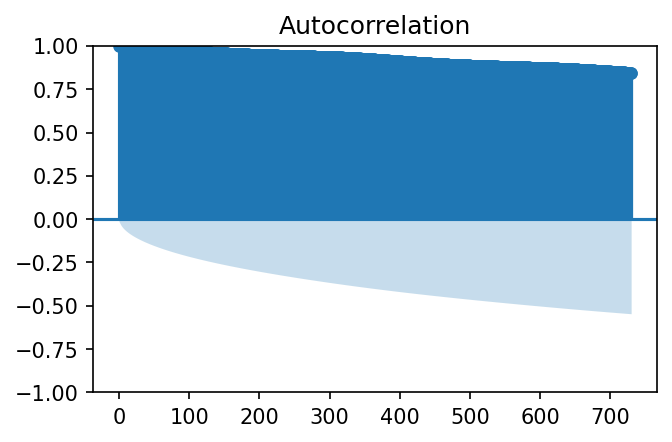

In [26]:
plot_acf(dat['pCO2'], lags=730);

(-0.05, 0.05)

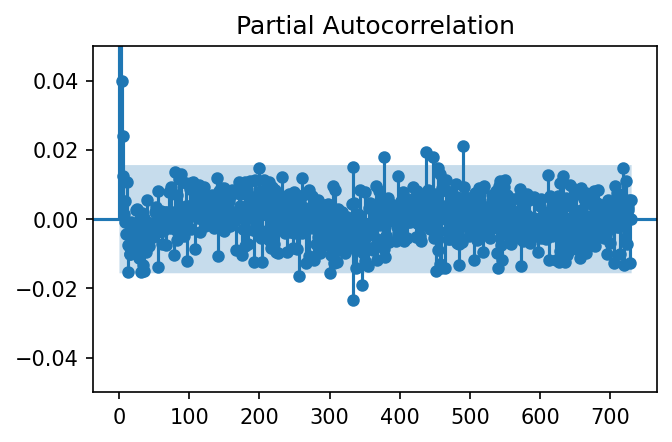

In [30]:
plot_pacf(dat['pCO2'], lags=730);
plt.ylim(-0.05, 0.05)

,year,month,day,pCO2
decimal_date,,,,
1974.3781,1974,5,19,333.46
1974.3808,1974,5,20,333.64
1974.3836,1974,5,21,333.50
1974.3863,1974,5,22,333.21
1974.3890,1974,5,23,333.05
...,...,...,...,...
2025.8110,2025,10,24,426.06
2025.8137,2025,10,25,425.22
2025.8164,2025,10,26,424.92
